In [35]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal

In [146]:
data = np.genfromtxt('data.csv', delimiter=";")

print(data)

[[ 2.97  0.    0.   ...  0.    0.    0.  ]
 [ 2.98  0.    0.   ...  0.   -0.    0.  ]
 [ 2.99  0.    0.   ...  0.   -0.    0.  ]
 ...
 [16.38  0.    0.   ...  0.    0.    0.  ]
 [16.38  0.    0.   ...  0.    0.    0.  ]
 [16.38  0.    0.   ...  0.    0.    0.  ]]


In [184]:
# remove duplicates
clean = []
times = []
for row in data:
    t = row[0]
    if t not in times:
        clean += [row]
        times += [t]

clean = np.asarray(clean)

print(clean)

[[ 2.97      0.        0.       ...  0.        0.        0.      ]
 [ 2.98      0.        0.       ...  0.       -0.        0.      ]
 [ 2.99      0.        0.       ...  0.       -0.        0.      ]
 ...
 [16.36      3.141758  1.007081 ...  3.141635  1.571281  3.141624]
 [16.37      3.141758  1.007081 ...  3.141635  1.571277  3.141625]
 [16.38      3.141758  1.007081 ...  3.141635  1.571273  3.141625]]


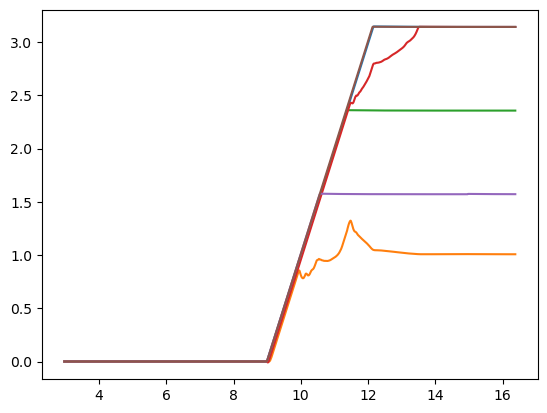

In [159]:
# reshape data
trans = clean.transpose()

t = trans[0]
chs = trans[1:]

for ch in chs:
    plt.plot(t, ch)
plt.show()

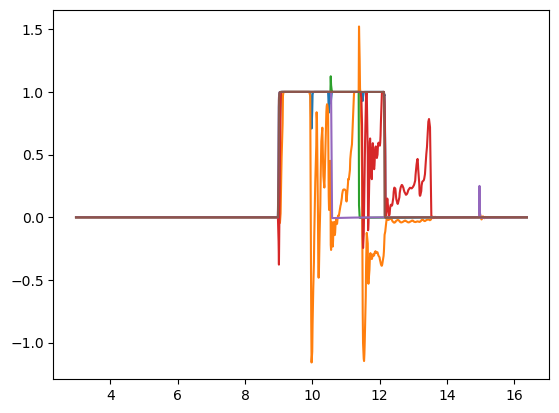

In [176]:
#derivate
ds = []
for ch in chs:
    d = []
    for y0, y1, x0, x1 in zip(ch[:-1], ch[1:], t[:-1], t[1:]):
        d += [(y1 - y0)/(x1 - x0)]
    ds += [d]
ds = np.asarray(ds)
ds_t = t[1:]

for d in ds:
    plt.plot(ds_t, d)
plt.show()

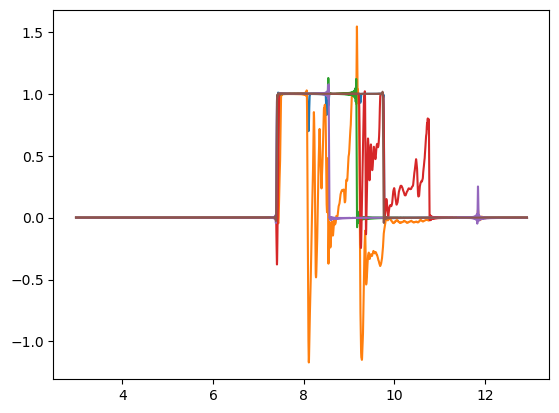

In [190]:
# resample it
rds, rds_t = signal.resample(ds,len(ds[0])*1000, ds_t, axis=1)

for rd in rds:
    plt.plot(rds_t, rd)
plt.show()

In [192]:
def calc_rt(ys, ts):
    t0, t1 = None, None
    
    for y, t in zip(ys, ts):
        if y >= 0.1:
            t0 = t
            break
            
    for y, t in zip(ys, ts):
        if y >= 0.9:
            t1 = t
            break
            
    return (t1 - t0) / 0.80

rts = list(map(lambda x: calc_rt(x, rds_t), rds))

print(rts)

[0.01842499999999969, 0.052075000000000315, 0.04757500000000192, 0.029274999999999718, 0.018287500000002677, 0.018975000000001074]
